# Phase 2 — Notebook 02: EDA & Feature Engineering

**From NB01:** EA features are the real deal (-0.037 log loss without ELO/DC masking them).
Best window: All data. Gap to Phase 1: 0.05.

**This notebook:**
1. Deep EDA on EA squad features — distributions, correlations, what matters
2. Feature engineering — new features from EA data
3. Full home/away features vs diffs
4. Correlation with match outcome
5. Quick model tests on new features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

DATA_DIR = Path('../../data')
PROCESSED_DIR = DATA_DIR / 'processed'

train_df = pd.read_csv(PROCESSED_DIR / 'train_dc.csv')
test_df = pd.read_csv(PROCESSED_DIR / 'test_dc.csv')
team_features = pd.read_csv(PROCESSED_DIR / 'team_features_by_year.csv')

train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])
train_df['year'] = train_df['date'].dt.year
test_df['year'] = test_df['date'].dt.year

print(f'Train: {len(train_df):,d} | Test: {len(test_df):,d}')
print(f'Team features: {team_features.shape}')

Train: 35,304 | Test: 3,313
Team features: (2831, 25)


## 1. EA Feature Deep Dive — What do we actually have?

In [2]:
SQUAD_FEATURES = [
    'squad_avg_overall', 'squad_median_overall', 'squad_std_overall',
    'squad_top3_avg', 'squad_bottom5_avg',
    'gk_avg', 'def_avg', 'mid_avg', 'fwd_avg',
    'strongest_unit', 'weakest_unit',
    'squad_total_value', 'squad_avg_value',
    'squad_avg_age', 'squad_avg_potential_gap', 'squad_avg_caps',
    'team_pace', 'team_shooting', 'team_passing',
    'team_dribbling', 'team_defending', 'team_physic',
]

# Look at 2022 snapshot (most data)
tf22 = team_features[team_features['year'] == 2022].copy()
print(f'2022: {len(tf22)} teams')
print(f'\nFeature stats:')
print(tf22[SQUAD_FEATURES].describe().T.to_string())

2022: 232 teams

Feature stats:
                         count          mean           std    min      25%     50%           75%           max
squad_avg_overall        232.0  6.448500e+01  8.119905e+00  45.00  58.7275  64.755  6.957750e+01  8.296000e+01
squad_median_overall     232.0  6.418888e+01  8.118645e+00  45.00  58.6900  64.410  6.950000e+01  8.300000e+01
squad_std_overall        232.0  4.281207e+00  2.027051e+00   0.00   2.8875   4.390  5.317500e+00  1.089000e+01
squad_top3_avg           232.0  6.997478e+01  9.733433e+00  45.00  63.2275  70.800  7.700000e+01  8.967000e+01
squad_bottom5_avg        232.0  6.036276e+01  7.972444e+00  45.00  53.9800  60.625  6.574000e+01  8.020000e+01
gk_avg                   232.0  6.449142e+01  8.844830e+00  45.00  58.2175  64.375  7.064250e+01  8.800000e+01
def_avg                  232.0  6.414392e+01  8.476363e+00  45.00  57.8600  65.275  6.960000e+01  8.250000e+01
mid_avg                  232.0  6.409621e+01  8.704351e+00  45.00  58.0450  64.5

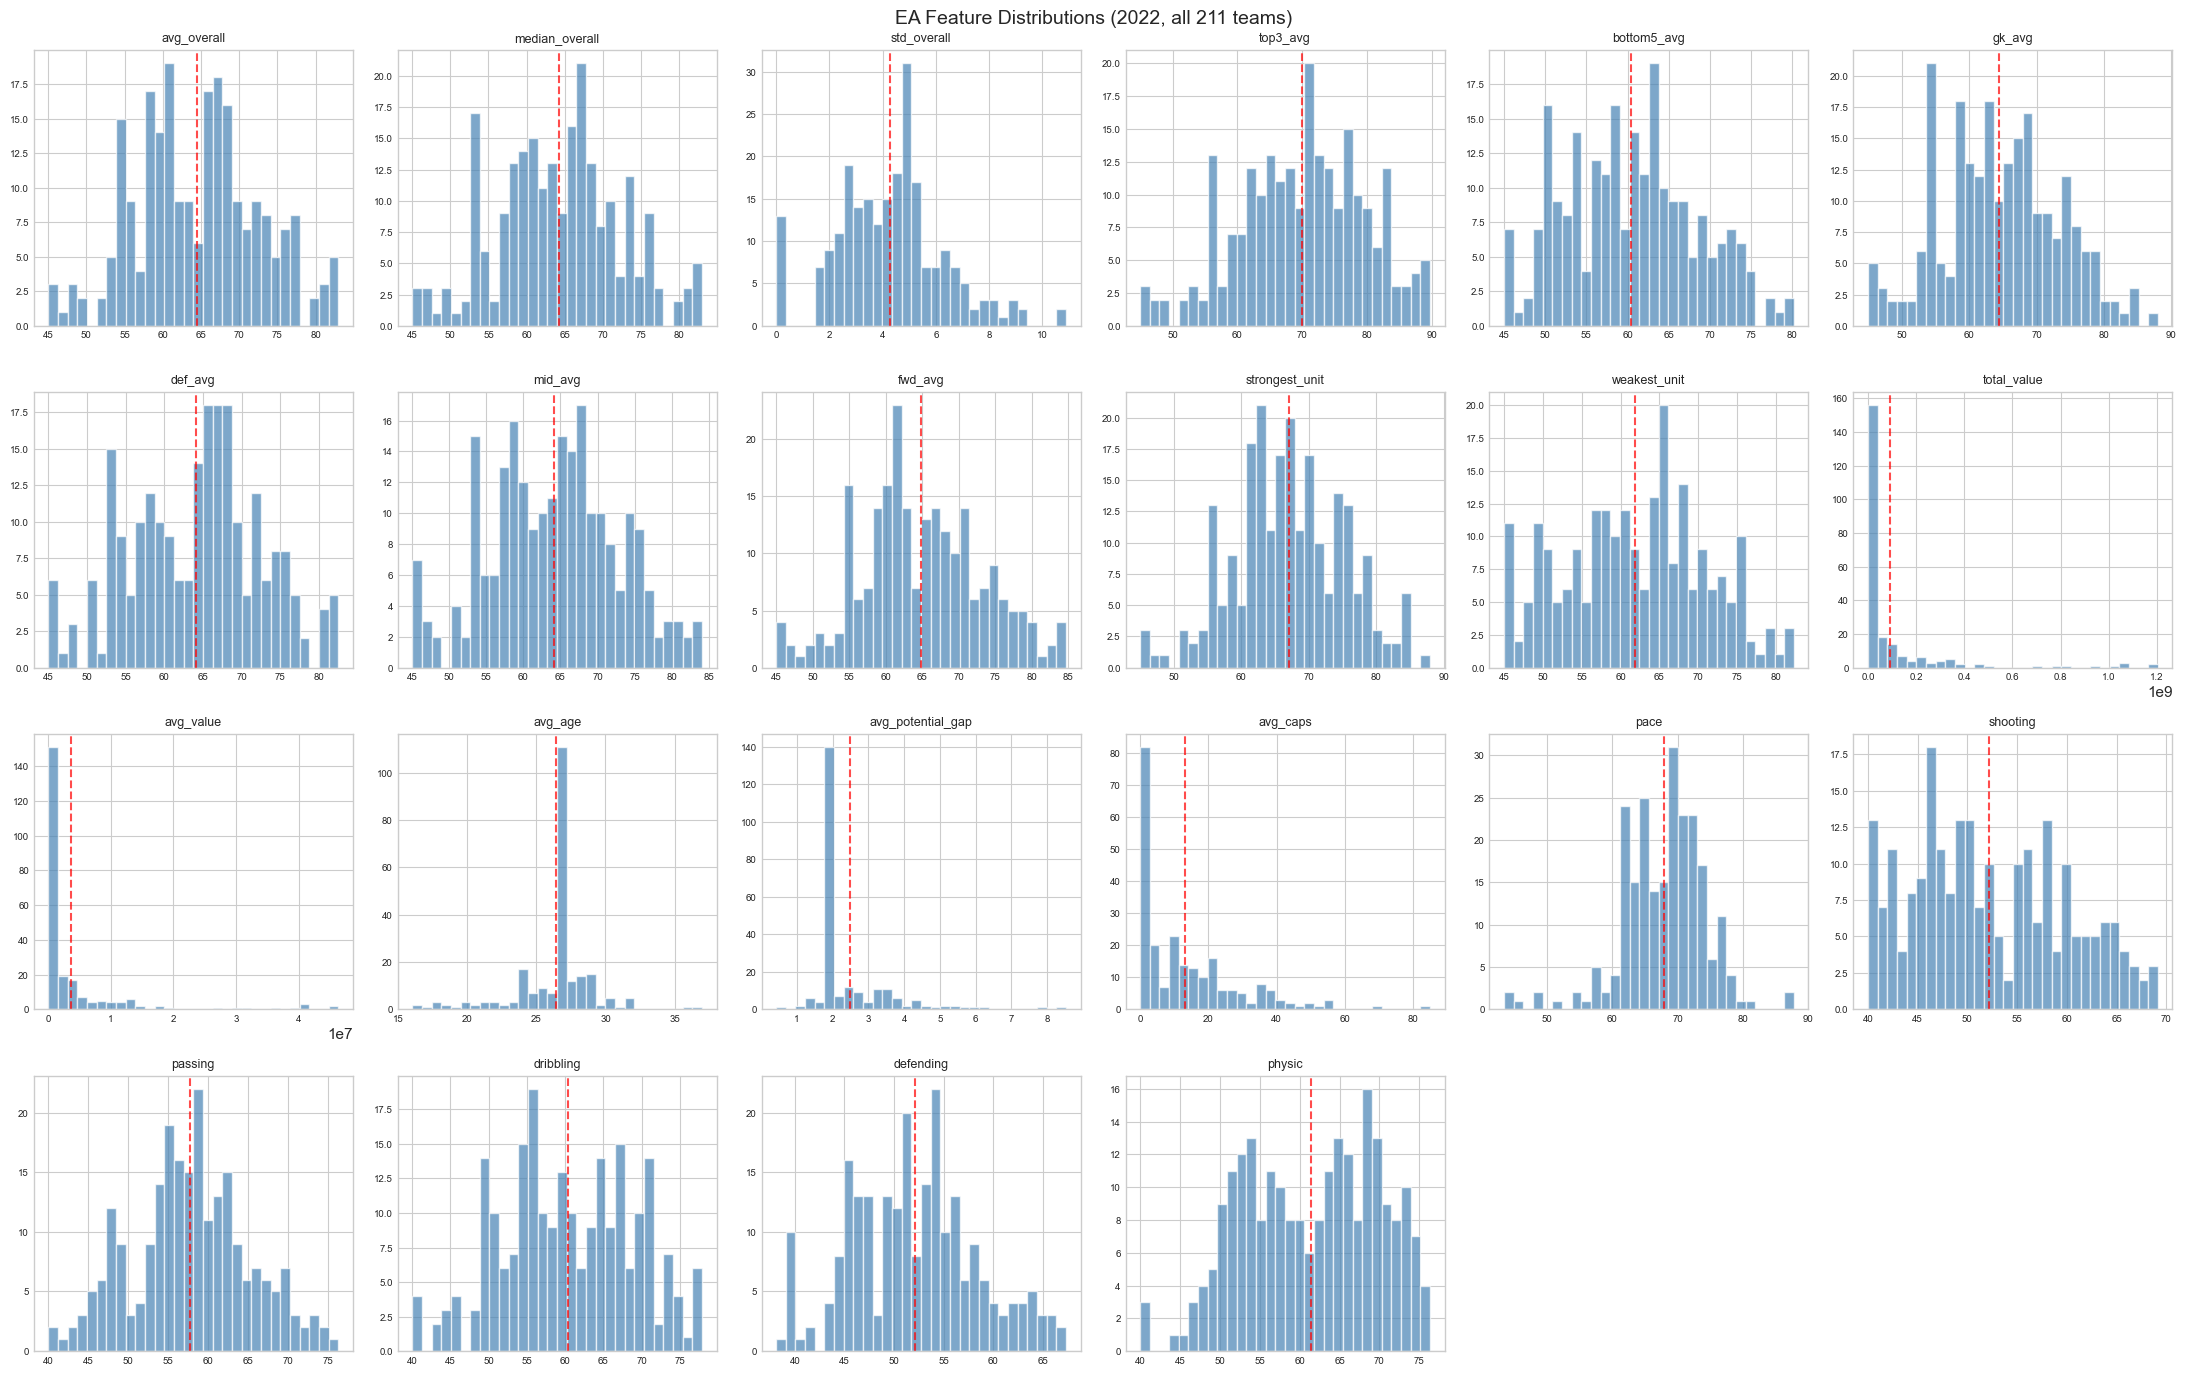

In [3]:
# Distribution of each EA feature
fig, axes = plt.subplots(4, 6, figsize=(22, 14))
axes = axes.flatten()

for i, feat in enumerate(SQUAD_FEATURES):
    if i < len(axes):
        ax = axes[i]
        vals = tf22[feat].dropna()
        ax.hist(vals, bins=30, alpha=0.7, color='steelblue', edgecolor='white')
        ax.set_title(feat.replace('squad_', '').replace('team_', ''), fontsize=9)
        ax.axvline(vals.mean(), color='red', linestyle='--', alpha=0.7)
        ax.tick_params(labelsize=7)

# Hide unused
for j in range(len(SQUAD_FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('EA Feature Distributions (2022, all 211 teams)', fontsize=14)
plt.tight_layout()
plt.savefig('../../notebooks/images/phase2_02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

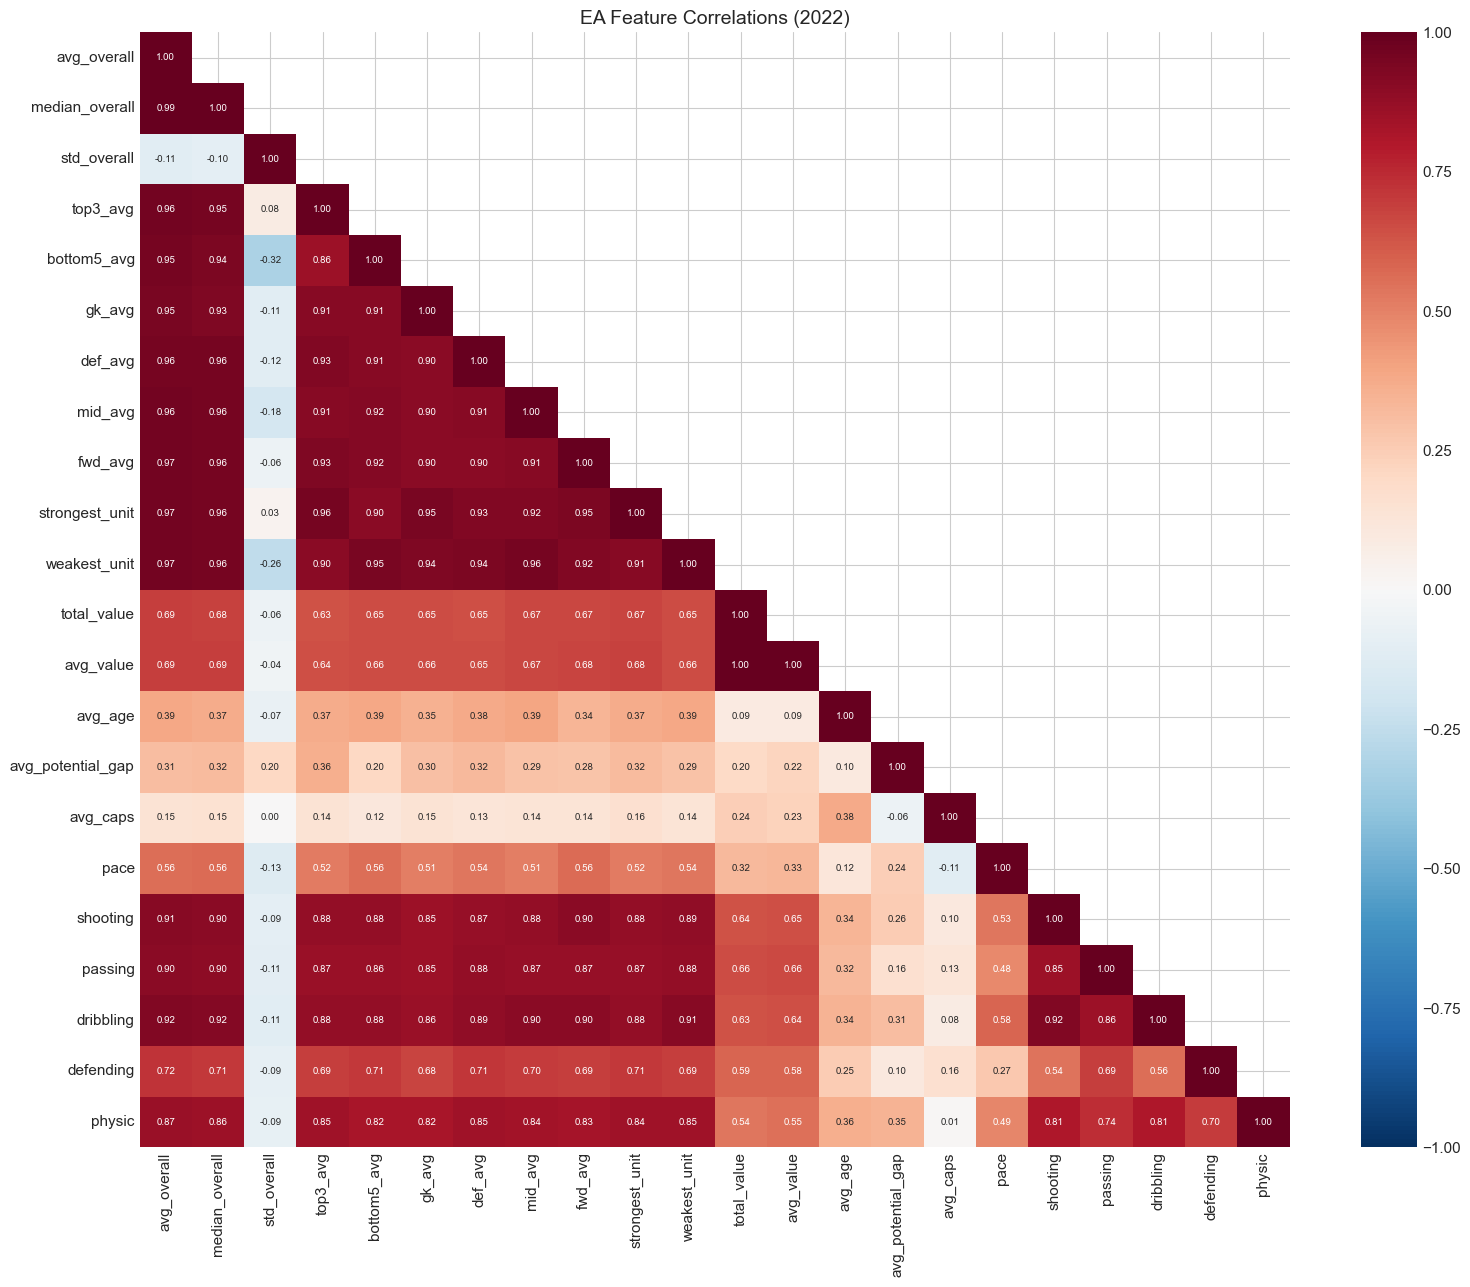


Highly correlated pairs (>0.95):
  squad_avg_overall              <-> squad_median_overall            r=0.993
  squad_avg_overall              <-> squad_top3_avg                  r=0.961
  squad_avg_overall              <-> squad_bottom5_avg               r=0.953
  squad_avg_overall              <-> def_avg                         r=0.961
  squad_avg_overall              <-> mid_avg                         r=0.961
  squad_avg_overall              <-> fwd_avg                         r=0.968
  squad_avg_overall              <-> strongest_unit                  r=0.968
  squad_avg_overall              <-> weakest_unit                    r=0.966
  squad_median_overall           <-> squad_top3_avg                  r=0.954
  squad_median_overall           <-> def_avg                         r=0.959
  squad_median_overall           <-> mid_avg                         r=0.956
  squad_median_overall           <-> fwd_avg                         r=0.960
  squad_median_overall           <-> stron

In [4]:
# Correlation matrix of EA features
fig, ax = plt.subplots(figsize=(16, 13))
corr = tf22[SQUAD_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, vmin=-1, vmax=1, annot_kws={'size': 7},
            xticklabels=[f.replace('squad_','').replace('team_','') for f in SQUAD_FEATURES],
            yticklabels=[f.replace('squad_','').replace('team_','') for f in SQUAD_FEATURES])
ax.set_title('EA Feature Correlations (2022)', fontsize=14)
plt.tight_layout()
plt.savefig('../../notebooks/images/phase2_02_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag highly correlated pairs (>0.95)
print('\nHighly correlated pairs (>0.95):')
for i in range(len(SQUAD_FEATURES)):
    for j in range(i+1, len(SQUAD_FEATURES)):
        if abs(corr.iloc[i, j]) > 0.95:
            print(f'  {SQUAD_FEATURES[i]:30s} <-> {SQUAD_FEATURES[j]:30s}  r={corr.iloc[i,j]:.3f}')

print('\nModerately correlated with squad_avg_overall:')
overall_corr = corr['squad_avg_overall'].drop('squad_avg_overall').sort_values(ascending=False)
for feat, r in overall_corr.items():
    print(f'  {feat:30s}  r={r:.3f}')

## 2. Which EA features correlate with match outcomes?

The real question: which features actually predict who wins?

In [5]:
# Join squad features to matches
def join_squad(df):
    df = df.copy()
    avail = sorted(team_features['year'].unique())
    def get_yr(y):
        c = [x for x in avail if x <= y]
        return max(c) if c else None
    df['fifa_year'] = df['year'].apply(get_yr)
    
    htf = team_features.rename(columns={f: f'home_{f}' for f in SQUAD_FEATURES})
    htf = htf.rename(columns={'team': 'home_team', 'year': 'fifa_year'})
    atf = team_features.rename(columns={f: f'away_{f}' for f in SQUAD_FEATURES})
    atf = atf.rename(columns={'team': 'away_team', 'year': 'fifa_year'})
    
    home_cols = ['home_team', 'fifa_year'] + [f'home_{f}' for f in SQUAD_FEATURES]
    away_cols = ['away_team', 'fifa_year'] + [f'away_{f}' for f in SQUAD_FEATURES]
    
    df = df.merge(htf[home_cols], on=['home_team', 'fifa_year'], how='left')
    df = df.merge(atf[away_cols], on=['away_team', 'fifa_year'], how='left')
    return df

train_aug = join_squad(train_df)
test_aug = join_squad(test_df)

# Filter to rows with squad data
has_sq = train_aug['home_squad_avg_overall'].notna() & train_aug['away_squad_avg_overall'].notna()
train_sq = train_aug[has_sq].copy()
print(f'Matches with squad data: {len(train_sq):,d} / {len(train_aug):,d}')

Matches with squad data: 6,072 / 35,304


In [6]:
# Compute ALL possible diff features
for f in SQUAD_FEATURES:
    train_sq[f'{f}_diff'] = train_sq[f'home_{f}'] - train_sq[f'away_{f}']

# Encode outcome as numeric: home_win=1, draw=0, away_win=-1
outcome_map = {'home_win': 1, 'draw': 0, 'away_win': -1}
train_sq['outcome_num'] = train_sq['outcome'].map(outcome_map)

# Correlation of each DIFF feature with outcome
diff_cols = [f'{f}_diff' for f in SQUAD_FEATURES]
correlations = train_sq[diff_cols + ['outcome_num']].corr()['outcome_num'].drop('outcome_num').sort_values(ascending=False)

print('Correlation with outcome (home_win=1, draw=0, away_win=-1):')
print('=' * 55)
for feat, r in correlations.items():
    bar = '█' * int(abs(r) * 100)
    print(f'  {feat:35s}  r={r:+.4f}  {bar}')

Correlation with outcome (home_win=1, draw=0, away_win=-1):
  squad_avg_overall_diff               r=+0.4596  █████████████████████████████████████████████
  weakest_unit_diff                    r=+0.4581  █████████████████████████████████████████████
  squad_median_overall_diff            r=+0.4545  █████████████████████████████████████████████
  fwd_avg_diff                         r=+0.4465  ████████████████████████████████████████████
  squad_top3_avg_diff                  r=+0.4432  ████████████████████████████████████████████
  mid_avg_diff                         r=+0.4428  ████████████████████████████████████████████
  def_avg_diff                         r=+0.4402  ████████████████████████████████████████████
  squad_bottom5_avg_diff               r=+0.4219  ██████████████████████████████████████████
  strongest_unit_diff                  r=+0.4175  █████████████████████████████████████████
  team_dribbling_diff                  r=+0.4168  █████████████████████████████████████

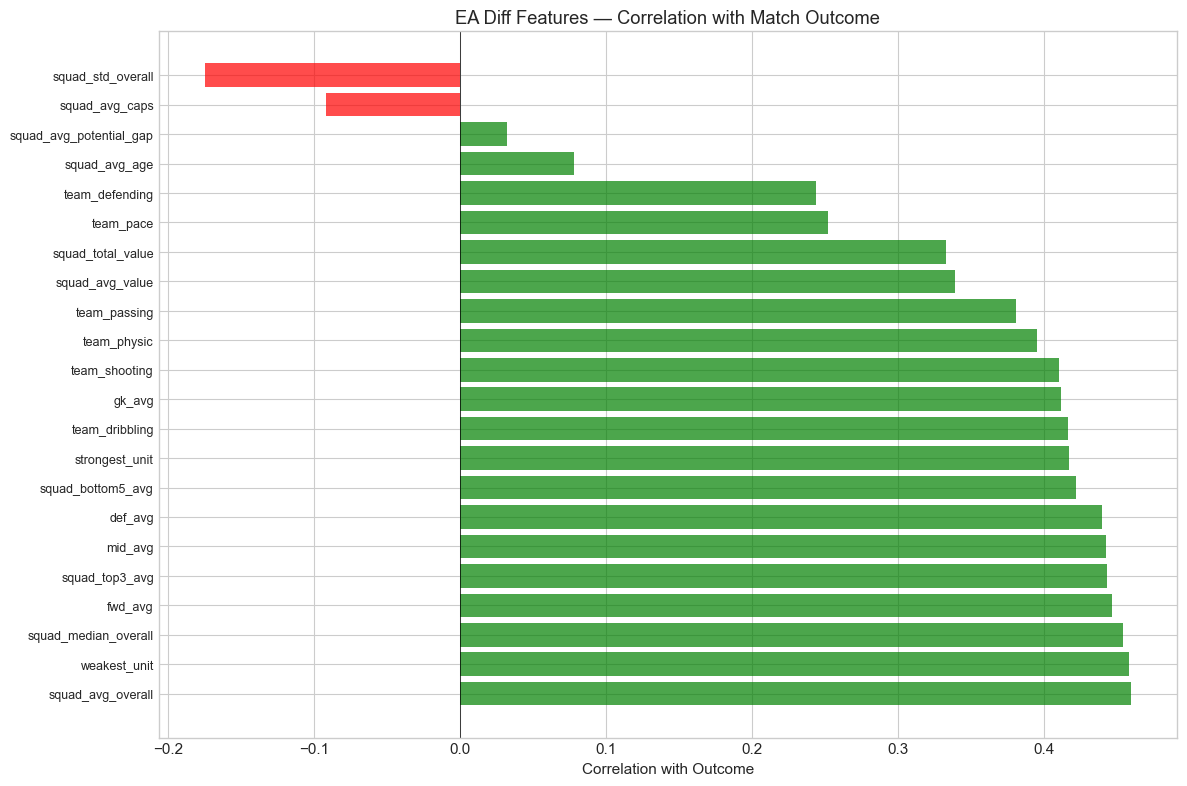

In [7]:
# Visualize top correlations
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['green' if v > 0 else 'red' for v in correlations.values]
ax.barh(range(len(correlations)), correlations.values, color=colors, alpha=0.7)
ax.set_yticks(range(len(correlations)))
ax.set_yticklabels([c.replace('_diff', '') for c in correlations.index], fontsize=9)
ax.set_xlabel('Correlation with Outcome')
ax.set_title('EA Diff Features — Correlation with Match Outcome')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('../../notebooks/images/phase2_02_outcome_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Also check: correlation of HOME-side and AWAY-side features with outcome
# (not just diffs — maybe absolute values matter too)
home_corrs = train_sq[[f'home_{f}' for f in SQUAD_FEATURES] + ['outcome_num']].corr()['outcome_num'].drop('outcome_num')
away_corrs = train_sq[[f'away_{f}' for f in SQUAD_FEATURES] + ['outcome_num']].corr()['outcome_num'].drop('outcome_num')

print(f'{"Feature":30s} | {"Home→outcome":>13s} | {"Away→outcome":>13s} | {"Diff→outcome":>13s}')
print('-' * 80)
for f in SQUAD_FEATURES:
    h = home_corrs.get(f'home_{f}', 0)
    a = away_corrs.get(f'away_{f}', 0)
    d = correlations.get(f'{f}_diff', 0)
    print(f'  {f:28s} | {h:+13.4f} | {a:+13.4f} | {d:+13.4f}')

Feature                        |  Home→outcome |  Away→outcome |  Diff→outcome
--------------------------------------------------------------------------------
  squad_avg_overall            |       +0.2126 |       -0.2725 |       +0.4596
  squad_median_overall         |       +0.2124 |       -0.2713 |       +0.4545
  squad_std_overall            |       -0.1255 |       +0.1144 |       -0.1747
  squad_top3_avg               |       +0.1980 |       -0.2548 |       +0.4432
  squad_bottom5_avg            |       +0.2062 |       -0.2643 |       +0.4219
  gk_avg                       |       +0.1929 |       -0.2528 |       +0.4120
  def_avg                      |       +0.2040 |       -0.2693 |       +0.4402
  mid_avg                      |       +0.2117 |       -0.2677 |       +0.4428
  fwd_avg                      |       +0.2163 |       -0.2693 |       +0.4465
  strongest_unit               |       +0.1922 |       -0.2550 |       +0.4175
  weakest_unit                 |       +0.2195 |  

## 3. Feature Engineering — New features from EA data

Ideas:
- **Ratios** instead of diffs (home/away overall ratio)
- **Squad balance** — gap between strongest and weakest unit
- **Star player impact** — top3 vs squad average (how star-dependent?)
- **Squad depth** — bottom5 avg, std of ratings
- **Style matchup** — pace diff, physical diff, etc.
- **Age profile** — young squads vs experienced
- **Value gap** — transfer value as proxy for quality

In [9]:
# === ENGINEER NEW FEATURES ===
df = train_sq.copy()

# --- RATIO FEATURES ---
# Ratio captures relative strength better than diff when absolute levels vary
df['overall_ratio'] = df['home_squad_avg_overall'] / df['away_squad_avg_overall'].clip(lower=1)
df['top3_ratio'] = df['home_squad_top3_avg'] / df['away_squad_top3_avg'].clip(lower=1)
df['value_ratio'] = (df['home_squad_total_value'] + 1) / (df['away_squad_total_value'] + 1)
df['value_ratio_log'] = np.log1p(df['home_squad_total_value']) - np.log1p(df['away_squad_total_value'])

# --- SQUAD BALANCE ---
# How balanced is the squad? A team with great defense but poor attack is different from all-round
df['home_squad_balance'] = df['home_strongest_unit'] - df['home_weakest_unit']
df['away_squad_balance'] = df['away_strongest_unit'] - df['away_weakest_unit']
df['squad_balance_diff'] = df['home_squad_balance'] - df['away_squad_balance']

# --- STAR DEPENDENCE ---
# High top3 but low avg = team depends on stars. Low gap = deep squad.
df['home_star_gap'] = df['home_squad_top3_avg'] - df['home_squad_avg_overall']
df['away_star_gap'] = df['away_squad_top3_avg'] - df['away_squad_avg_overall']
df['star_gap_diff'] = df['home_star_gap'] - df['away_star_gap']

# --- SQUAD DEPTH ---
# Bottom 5 avg — how good are the weakest starters?
df['depth_diff'] = df['home_squad_bottom5_avg'] - df['away_squad_bottom5_avg']
# Std — higher std = more unequal squad
df['squad_std_diff'] = df['home_squad_std_overall'] - df['away_squad_std_overall']

# --- POSITIONAL MATCHUP ---
# Attacking strength vs opposing defense
df['home_attack_vs_def'] = df['home_fwd_avg'] - df['away_def_avg']
df['away_attack_vs_def'] = df['away_fwd_avg'] - df['home_def_avg']
df['attack_vs_def_diff'] = df['home_attack_vs_def'] - df['away_attack_vs_def']

# Midfield battle
df['mid_battle'] = df['home_mid_avg'] - df['away_mid_avg']

# GK difference
df['gk_diff'] = df['home_gk_avg'] - df['away_gk_avg']

# --- STYLE FEATURES ---
# Pace vs Physic — counter-attacking vs physical play
df['home_pace_physic_ratio'] = df['home_team_pace'] / df['home_team_physic'].clip(lower=1)
df['away_pace_physic_ratio'] = df['away_team_pace'] / df['away_team_physic'].clip(lower=1)
df['pace_diff'] = df['home_team_pace'] - df['away_team_pace']
df['physic_diff'] = df['home_team_physic'] - df['away_team_physic']
df['shooting_diff'] = df['home_team_shooting'] - df['away_team_shooting']
df['passing_diff'] = df['home_team_passing'] - df['away_team_passing']
df['defending_diff'] = df['home_team_defending'] - df['away_team_defending']
df['dribbling_diff'] = df['home_team_dribbling'] - df['away_team_dribbling']

# --- AGE & EXPERIENCE ---
df['age_diff'] = df['home_squad_avg_age'] - df['away_squad_avg_age']
df['caps_diff'] = df['home_squad_avg_caps'] - df['away_squad_avg_caps']
df['potential_gap_diff'] = df['home_squad_avg_potential_gap'] - df['away_squad_avg_potential_gap']

# --- COMPOSITE STRENGTH ---
# Weighted overall: top3 matters more for knockout, avg for group stages
df['home_weighted_strength'] = 0.6 * df['home_squad_avg_overall'] + 0.4 * df['home_squad_top3_avg']
df['away_weighted_strength'] = 0.6 * df['away_squad_avg_overall'] + 0.4 * df['away_squad_top3_avg']
df['weighted_strength_diff'] = df['home_weighted_strength'] - df['away_weighted_strength']

print('Engineered features created.')
print(f'Total columns: {len(df.columns)}')

Engineered features created.
Total columns: 170


In [10]:
# Correlation of ALL new features with outcome
new_features = [
    'overall_ratio', 'top3_ratio', 'value_ratio', 'value_ratio_log',
    'squad_balance_diff', 'star_gap_diff', 'depth_diff', 'squad_std_diff',
    'home_attack_vs_def', 'away_attack_vs_def', 'attack_vs_def_diff',
    'mid_battle', 'gk_diff',
    'pace_diff', 'physic_diff', 'shooting_diff', 'passing_diff',
    'defending_diff', 'dribbling_diff',
    'age_diff', 'caps_diff', 'potential_gap_diff',
    'weighted_strength_diff',
]

# Also include original diffs for comparison
original_diffs = [
    'squad_avg_overall_diff', 'squad_top3_avg_diff', 'squad_total_value_diff',
    'def_avg_diff', 'mid_avg_diff', 'fwd_avg_diff',
]

all_candidate_features = original_diffs + new_features
corr_with_outcome = df[all_candidate_features + ['outcome_num']].corr()['outcome_num'].drop('outcome_num').sort_values(ascending=False)

print('ALL features — Correlation with outcome:')
print('=' * 60)
for feat, r in corr_with_outcome.items():
    is_new = '★ NEW' if feat in new_features else '      '
    bar = '█' * int(abs(r) * 80)
    print(f'  {feat:35s}  r={r:+.4f}  {is_new}  {bar}')

ALL features — Correlation with outcome:
  weighted_strength_diff               r=+0.4605  ★ NEW  ████████████████████████████████████
  attack_vs_def_diff                   r=+0.4601  ★ NEW  ████████████████████████████████████
  squad_avg_overall_diff               r=+0.4596          ████████████████████████████████████
  home_attack_vs_def                   r=+0.4471  ★ NEW  ███████████████████████████████████
  fwd_avg_diff                         r=+0.4465          ███████████████████████████████████
  squad_top3_avg_diff                  r=+0.4432          ███████████████████████████████████
  mid_battle                           r=+0.4428  ★ NEW  ███████████████████████████████████
  mid_avg_diff                         r=+0.4428          ███████████████████████████████████
  def_avg_diff                         r=+0.4402          ███████████████████████████████████
  overall_ratio                        r=+0.4341  ★ NEW  ██████████████████████████████████
  depth_diff          

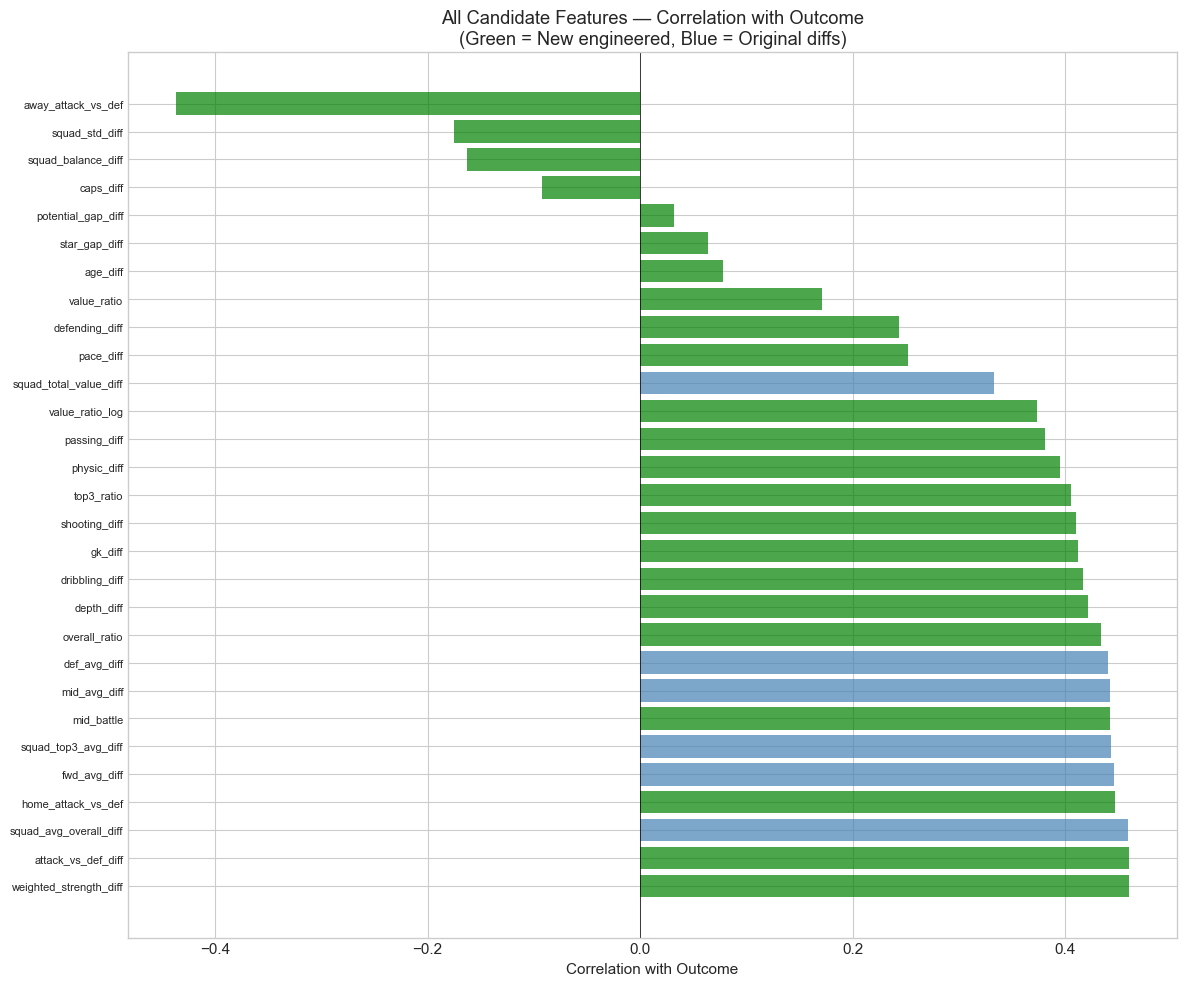

In [11]:
# Visualize: old vs new features correlation with outcome
fig, ax = plt.subplots(figsize=(12, 10))

colors = ['green' if f in new_features else 'steelblue' for f in corr_with_outcome.index]
ax.barh(range(len(corr_with_outcome)), corr_with_outcome.values, color=colors, alpha=0.7)
ax.set_yticks(range(len(corr_with_outcome)))
ax.set_yticklabels(corr_with_outcome.index, fontsize=8)
ax.set_xlabel('Correlation with Outcome')
ax.set_title('All Candidate Features — Correlation with Outcome\n(Green = New engineered, Blue = Original diffs)')
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../../notebooks/images/phase2_02_all_features_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Redundancy Check — Which features are independent?

Many features may be highly correlated with each other. We want features that each add NEW information.

Features with |r| > 0.15 with outcome: 25


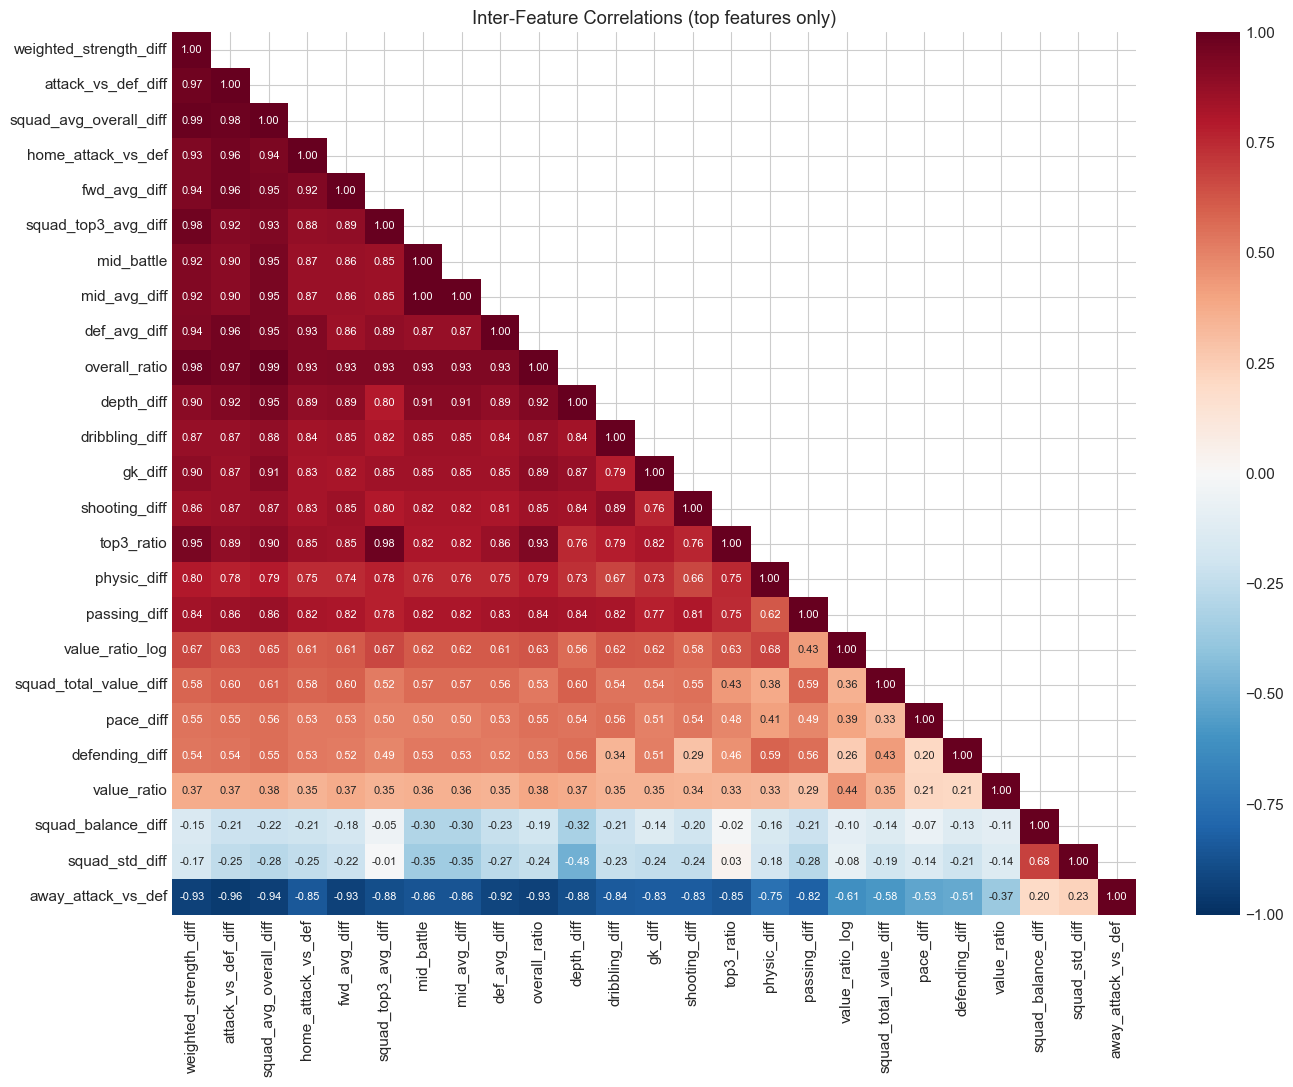


Correlation clusters (>0.90):
  Cluster: weighted_strength_diff, attack_vs_def_diff, squad_avg_overall_diff, home_attack_vs_def, fwd_avg_diff, squad_top3_avg_diff, mid_battle, mid_avg_diff, def_avg_diff, overall_ratio, top3_ratio, away_attack_vs_def
    Best: weighted_strength_diff (r=+0.4605)


In [12]:
# Inter-feature correlation
top_features = corr_with_outcome[abs(corr_with_outcome) > 0.15].index.tolist()
print(f'Features with |r| > 0.15 with outcome: {len(top_features)}')

if len(top_features) > 2:
    fig, ax = plt.subplots(figsize=(14, 11))
    inter_corr = df[top_features].corr()
    mask = np.triu(np.ones_like(inter_corr, dtype=bool), k=1)
    sns.heatmap(inter_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                ax=ax, vmin=-1, vmax=1, annot_kws={'size': 8})
    ax.set_title('Inter-Feature Correlations (top features only)')
    plt.tight_layout()
    plt.savefig('../../notebooks/images/phase2_02_inter_feature_corr.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Flag highly correlated groups
    print('\nCorrelation clusters (>0.90):')
    seen = set()
    for i, f1 in enumerate(top_features):
        cluster = [f1]
        for j, f2 in enumerate(top_features):
            if i != j and abs(inter_corr.loc[f1, f2]) > 0.90 and f2 not in seen:
                cluster.append(f2)
        if len(cluster) > 1 and f1 not in seen:
            outcome_r = [corr_with_outcome.get(f, 0) for f in cluster]
            best_idx = np.argmax([abs(r) for r in outcome_r])
            print(f'  Cluster: {", ".join(cluster)}')
            print(f'    Best: {cluster[best_idx]} (r={outcome_r[best_idx]:+.4f})')
            seen.update(cluster)

## 5. Feature Selection — Build the final clean feature set

Pick features that are:
1. Correlated with outcome (|r| > threshold)
2. Not redundant with each other (<0.90 inter-correlation)
3. From each cluster, keep only the best

In [14]:
# Greedy feature selection: pick features that add independent signal
def greedy_select(candidates, df, target='outcome_num', max_corr=0.85):
    """Select features greedily: highest outcome correlation first,
    skip if too correlated with already-selected features."""
    selected = []
    for feat in candidates:
        if feat not in df.columns:
            continue
        if not selected:
            selected.append(feat)
            continue
        # Check correlation with all already-selected
        too_corr = False
        for sel in selected:
            r = df[[feat, sel]].corr().iloc[0, 1]
            if abs(r) > max_corr:
                too_corr = True
                break
        if not too_corr:
            selected.append(feat)
    return selected

# Sort all candidates by absolute correlation with outcome
sorted_candidates = corr_with_outcome.reindex(corr_with_outcome.abs().sort_values(ascending=False).index).index.tolist()

selected_ea = greedy_select(sorted_candidates, df, max_corr=0.85)

print(f'Selected {len(selected_ea)} EA features (greedy, max_corr=0.85):')
for f in selected_ea:
    r = corr_with_outcome[f]
    is_new = '★' if f in new_features else ' '
    print(f'  {is_new} {f:35s}  r={r:+.4f}')

Selected 14 EA features (greedy, max_corr=0.85):
  ★ weighted_strength_diff               r=+0.4605
  ★ physic_diff                          r=+0.3951
  ★ passing_diff                         r=+0.3812
  ★ value_ratio_log                      r=+0.3734
    squad_total_value_diff               r=+0.3332
  ★ pace_diff                            r=+0.2523
  ★ defending_diff                       r=+0.2437
  ★ squad_std_diff                       r=-0.1747
  ★ value_ratio                          r=+0.1711
  ★ squad_balance_diff                   r=-0.1627
  ★ caps_diff                            r=-0.0919
  ★ age_diff                             r=+0.0778
  ★ star_gap_diff                        r=+0.0635
  ★ potential_gap_diff                   r=+0.0321


## 6. Quick Model Test — Do new features help?

In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import log_loss, accuracy_score
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb

# Form + H2H + Context (same as NB01)
FORM_FEATURES = [
    'home_win_rate_5', 'home_avg_scored_5', 'home_avg_conceded_5',
    'home_pts_per_match_5', 'home_matches_played_5',
    'home_win_rate_10', 'home_avg_scored_10', 'home_avg_conceded_10',
    'home_pts_per_match_10', 'home_matches_played_10',
    'away_win_rate_5', 'away_avg_scored_5', 'away_avg_conceded_5',
    'away_pts_per_match_5', 'away_matches_played_5',
    'away_win_rate_10', 'away_avg_scored_10', 'away_avg_conceded_10',
    'away_pts_per_match_10', 'away_matches_played_10',
]
FORM_ENGINEERED = [
    'home_form_momentum', 'away_form_momentum',
    'home_goal_diff_form', 'away_goal_diff_form', 'net_goal_diff',
]
H2H_FEATURES = [
    'h2h_home_win_rate', 'h2h_home_avg_scored', 'h2h_home_avg_conceded',
    'h2h_total_meetings', 'h2h_recent_win_rate', 'h2h_confidence',
]
CONTEXT_FEATURES = [
    'neutral.1', 'tournament_importance',
    'home_conf_UEFA', 'home_conf_CAF', 'home_conf_AFC',
    'home_conf_CONCACAF', 'home_conf_CONMEBOL', 'home_conf_OFC', 'home_conf_UNKNOWN',
    'away_conf_UEFA', 'away_conf_CAF', 'away_conf_AFC',
    'away_conf_CONCACAF', 'away_conf_CONMEBOL', 'away_conf_OFC', 'away_conf_UNKNOWN',
    'same_confederation',
]

BASE_CLEAN = FORM_FEATURES + FORM_ENGINEERED + H2H_FEATURES + CONTEXT_FEATURES

# Original 9 diff features
OLD_DIFFS = [
    'squad_avg_overall_diff', 'squad_top3_avg_diff', 'squad_total_value_diff',
    'def_avg_diff', 'mid_avg_diff', 'fwd_avg_diff',
    'team_shooting_diff', 'team_passing_diff', 'team_defending_diff',
]

# Note: we need to compute new features for test set too
print(f'Base clean features: {len(BASE_CLEAN)}')
print(f'Old EA diffs: {len(OLD_DIFFS)}')
print(f'New selected EA: {len(selected_ea)}')

Base clean features: 48
Old EA diffs: 9
New selected EA: 14


In [16]:
# Engineer features for FULL train and test sets
def engineer_features(df):
    df = df.copy()
    # All diffs
    for f in SQUAD_FEATURES:
        df[f'{f}_diff'] = df[f'home_{f}'] - df[f'away_{f}']
    
    # Ratios
    df['overall_ratio'] = df['home_squad_avg_overall'] / df['away_squad_avg_overall'].clip(lower=1)
    df['top3_ratio'] = df['home_squad_top3_avg'] / df['away_squad_top3_avg'].clip(lower=1)
    df['value_ratio'] = (df['home_squad_total_value'] + 1) / (df['away_squad_total_value'] + 1)
    df['value_ratio_log'] = np.log1p(df['home_squad_total_value']) - np.log1p(df['away_squad_total_value'])
    
    # Squad balance
    df['home_squad_balance'] = df['home_strongest_unit'] - df['home_weakest_unit']
    df['away_squad_balance'] = df['away_strongest_unit'] - df['away_weakest_unit']
    df['squad_balance_diff'] = df['home_squad_balance'] - df['away_squad_balance']
    
    # Star dependence
    df['home_star_gap'] = df['home_squad_top3_avg'] - df['home_squad_avg_overall']
    df['away_star_gap'] = df['away_squad_top3_avg'] - df['away_squad_avg_overall']
    df['star_gap_diff'] = df['home_star_gap'] - df['away_star_gap']
    
    # Depth
    df['depth_diff'] = df['home_squad_bottom5_avg'] - df['away_squad_bottom5_avg']
    df['squad_std_diff'] = df['home_squad_std_overall'] - df['away_squad_std_overall']
    
    # Positional matchup
    df['home_attack_vs_def'] = df['home_fwd_avg'] - df['away_def_avg']
    df['away_attack_vs_def'] = df['away_fwd_avg'] - df['home_def_avg']
    df['attack_vs_def_diff'] = df['home_attack_vs_def'] - df['away_attack_vs_def']
    df['mid_battle'] = df['home_mid_avg'] - df['away_mid_avg']
    df['gk_diff'] = df['home_gk_avg'] - df['away_gk_avg']
    
    # Style
    df['pace_diff'] = df['home_team_pace'] - df['away_team_pace']
    df['physic_diff'] = df['home_team_physic'] - df['away_team_physic']
    df['shooting_diff'] = df['home_team_shooting'] - df['away_team_shooting']
    df['passing_diff'] = df['home_team_passing'] - df['away_team_passing']
    df['defending_diff'] = df['home_team_defending'] - df['away_team_defending']
    df['dribbling_diff'] = df['home_team_dribbling'] - df['away_team_dribbling']
    
    # Age & Experience
    df['age_diff'] = df['home_squad_avg_age'] - df['away_squad_avg_age']
    df['caps_diff'] = df['home_squad_avg_caps'] - df['away_squad_avg_caps']
    df['potential_gap_diff'] = df['home_squad_avg_potential_gap'] - df['away_squad_avg_potential_gap']
    
    # Composite
    df['home_weighted_strength'] = 0.6 * df['home_squad_avg_overall'] + 0.4 * df['home_squad_top3_avg']
    df['away_weighted_strength'] = 0.6 * df['away_squad_avg_overall'] + 0.4 * df['away_squad_top3_avg']
    df['weighted_strength_diff'] = df['home_weighted_strength'] - df['away_weighted_strength']
    
    return df

train_eng = engineer_features(train_aug)
test_eng = engineer_features(test_aug)

le = LabelEncoder()
y_train = le.fit_transform(train_eng['outcome'].values)
y_test = le.transform(test_eng['outcome'].values)

print(f'Train: {len(train_eng):,d} | Test: {len(test_eng):,d}')
print(f'Engineered columns: {len(train_eng.columns)}')

Train: 35,304 | Test: 3,313
Engineered columns: 168


In [17]:
# === MODEL COMPARISON ===
XGB_P = dict(n_estimators=200, max_depth=5, learning_rate=0.05,
             subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0)

results = []

def test_features(name, feature_cols):
    # Verify all features exist
    missing = [f for f in feature_cols if f not in train_eng.columns]
    if missing:
        print(f'  WARNING: missing features: {missing}')
        feature_cols = [f for f in feature_cols if f in train_eng.columns]
    
    X_tr = train_eng[feature_cols].values
    X_te = test_eng[feature_cols].values
    
    model = CalibratedClassifierCV(
        xgb.XGBClassifier(**XGB_P, eval_metric='mlogloss', random_state=42, verbosity=0),
        method='isotonic', cv=5)
    model.fit(X_tr, y_train)
    p = model.predict_proba(X_te)
    
    ll = log_loss(y_test, p)
    acc = accuracy_score(y_test, np.argmax(p, axis=1))
    results.append((name, len(feature_cols), ll, acc))
    print(f'  {name:50s} | {len(feature_cols):>3d} feat | ll={ll:.4f} | acc={acc:.4f}')
    return model, p

print('FEATURE SET COMPARISON (all on full 35K train, 3.3K test, NO ELO/DC)')
print('=' * 85)

# A: Baseline — form+H2H+context only (no EA)
test_features('A: Base clean (no EA)', BASE_CLEAN)

# B: NB01 best — base + 9 original diffs
test_features('B: Base + 9 original EA diffs', BASE_CLEAN + OLD_DIFFS)

# C: Base + ALL 22 diffs
all_22_diffs = [f'{f}_diff' for f in SQUAD_FEATURES]
test_features('C: Base + 22 EA diffs (all)', BASE_CLEAN + all_22_diffs)

# D: Base + greedy-selected EA features
test_features('D: Base + greedy-selected EA', BASE_CLEAN + selected_ea)

# E: Base + ALL new engineered features
all_new = all_22_diffs + new_features
test_features('E: Base + ALL engineered (diffs + new)', BASE_CLEAN + all_new)

# F: Base + selected EA + home/away absolute features
home_away_abs = [f'home_{f}' for f in SQUAD_FEATURES] + [f'away_{f}' for f in SQUAD_FEATURES]
test_features('F: Base + selected EA + home/away absolute', BASE_CLEAN + selected_ea + home_away_abs)

# G: ONLY EA features (no form, no H2H, no context) — how strong is EA alone?
test_features('G: EA features ONLY (no form/H2H)', selected_ea + home_away_abs)

FEATURE SET COMPARISON (all on full 35K train, 3.3K test, NO ELO/DC)
  A: Base clean (no EA)                              |  48 feat | ll=0.8762 | acc=0.5976
  B: Base + 9 original EA diffs                      |  57 feat | ll=0.8499 | acc=0.6142
  C: Base + 22 EA diffs (all)                        |  70 feat | ll=0.8491 | acc=0.6161
  D: Base + greedy-selected EA                       |  62 feat | ll=0.8582 | acc=0.6158
  E: Base + ALL engineered (diffs + new)             |  93 feat | ll=0.8489 | acc=0.6167
  F: Base + selected EA + home/away absolute         | 106 feat | ll=0.8495 | acc=0.6155
  G: EA features ONLY (no form/H2H)                  |  58 feat | ll=0.9794 | acc=0.5038


(CalibratedClassifierCV(cv=5,
                        estimator=XGBClassifier(base_score=None, booster=None,
                                                callbacks=None,
                                                colsample_bylevel=None,
                                                colsample_bynode=None,
                                                colsample_bytree=0.8,
                                                device=None,
                                                early_stopping_rounds=None,
                                                enable_categorical=False,
                                                eval_metric='mlogloss',
                                                feature_types=None,
                                                feature_weights=None, gamma=None,
                                                grow_policy=None,
                                                importance_type=None,
                                             

In [18]:
# Results summary
print('\n' + '=' * 85)
print('RESULTS — sorted by log loss')
print('=' * 85)
print(f'{"Model":50s} | {"Feat":>4s} | {"LL":>8s} | {"Acc":>7s}')
print('-' * 80)
for name, n_feat, ll, acc in sorted(results, key=lambda x: x[2]):
    print(f'{name:50s} | {n_feat:>4d} | {ll:>8.4f} | {acc:>7.4f}')

# Best
best = min(results, key=lambda x: x[2])
nb01_best = 0.8499  # from NB01: All + Clean + EA diff
print(f'\nBest: {best[0]} — ll={best[2]:.4f}')
print(f'vs NB01 best (9 diffs):     {nb01_best:.4f} (delta: {best[2]-nb01_best:+.4f})')
print(f'vs Phase 1 (ELO+DC):        0.7988 (gap: {best[2]-0.7988:+.4f})')


RESULTS — sorted by log loss
Model                                              | Feat |       LL |     Acc
--------------------------------------------------------------------------------
E: Base + ALL engineered (diffs + new)             |   93 |   0.8489 |  0.6167
C: Base + 22 EA diffs (all)                        |   70 |   0.8491 |  0.6161
F: Base + selected EA + home/away absolute         |  106 |   0.8495 |  0.6155
B: Base + 9 original EA diffs                      |   57 |   0.8499 |  0.6142
D: Base + greedy-selected EA                       |   62 |   0.8582 |  0.6158
A: Base clean (no EA)                              |   48 |   0.8762 |  0.5976
G: EA features ONLY (no form/H2H)                  |   58 |   0.9794 |  0.5038

Best: E: Base + ALL engineered (diffs + new) — ll=0.8489
vs NB01 best (9 diffs):     0.8499 (delta: -0.0010)
vs Phase 1 (ELO+DC):        0.7988 (gap: +0.0501)


In [19]:
# Feature importance from best model
best_name = min(results, key=lambda x: x[2])[0]
# Re-train best to get importance
if 'D:' in best_name:
    feat_cols = BASE_CLEAN + selected_ea
elif 'E:' in best_name:
    feat_cols = BASE_CLEAN + all_new
elif 'F:' in best_name:
    feat_cols = BASE_CLEAN + selected_ea + home_away_abs
elif 'C:' in best_name:
    feat_cols = BASE_CLEAN + all_22_diffs
else:
    feat_cols = BASE_CLEAN + OLD_DIFFS

xgb_raw = xgb.XGBClassifier(**XGB_P, eval_metric='mlogloss', random_state=42, verbosity=0)
xgb_raw.fit(train_eng[feat_cols].values, y_train)
imp = xgb_raw.feature_importances_

feat_imp = sorted(zip(feat_cols, imp), key=lambda x: -x[1])

print(f'\nTop 25 Feature Importance ({best_name}):')
print('=' * 60)
for i, (f, v) in enumerate(feat_imp[:25]):
    is_ea = f not in BASE_CLEAN
    marker = ' ★ EA' if is_ea else ''
    bar = '█' * int(v * 300)
    print(f'  {i+1:2d}. {f:35s}  {v:.4f}  {bar}{marker}')

# How much total importance is EA?
ea_imp = sum(v for f, v in feat_imp if f not in BASE_CLEAN)
base_imp = sum(v for f, v in feat_imp if f in BASE_CLEAN)
print(f'\nTotal importance: EA={ea_imp:.3f} ({ea_imp/(ea_imp+base_imp)*100:.1f}%) | Base={base_imp:.3f} ({base_imp/(ea_imp+base_imp)*100:.1f}%)')


Top 25 Feature Importance (E: Base + ALL engineered (diffs + new)):
   1. h2h_home_win_rate                    0.1031  ██████████████████████████████
   2. net_goal_diff                        0.0847  █████████████████████████
   3. h2h_recent_win_rate                  0.0470  ██████████████
   4. h2h_home_avg_conceded                0.0231  ██████
   5. away_avg_conceded_10                 0.0169  █████
   6. away_conf_CAF                        0.0168  █████
   7. weighted_strength_diff               0.0153  ████ ★ EA
   8. h2h_confidence                       0.0149  ████
   9. away_conf_UEFA                       0.0146  ████
  10. top3_ratio                           0.0141  ████ ★ EA
  11. home_goal_diff_form                  0.0134  ████
  12. h2h_home_avg_scored                  0.0132  ███
  13. home_avg_conceded_10                 0.0127  ███
  14. away_pts_per_match_10                0.0124  ███
  15. home_conf_CAF                        0.0124  ███
  16. home_pts_per_match

## 7. Summary & Next Steps

**Key findings:**
1. Which new features add value?
2. Which are redundant?
3. What's the best feature set so far (no ELO/DC)?
4. How much of the 0.05 gap to Phase 1 did we close?

**Next:** Notebook 03 — Model tuning + architecture search on the final feature set